In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

# Завдання 0. Підготовка


In [2]:
file_id = '1xnLTugNtRwIa-Q_lhO0rAKP_8mJnVkPj'
url=f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)

df.head()

,name,release_date,developer,publisher,platforms,required_age,genres,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,Counter-Strike,2000-11-01,Valve,Valve,windows;mac;linux,0,Action,0,124534,3339,17612,317,15000000.0,7.19
1,Team Fortress Classic,1999-04-01,Valve,Valve,windows;mac;linux,0,Action,0,3318,633,277,62,7500000.0,3.99
2,Day of Defeat,2003-05-01,Valve,Valve,windows;mac;linux,0,Action,0,3416,398,187,34,7500000.0,3.99
3,Deathmatch Classic,2001-06-01,Valve,Valve,windows;mac;linux,0,Action,0,1273,267,258,184,7500000.0,3.99
4,Half-Life: Opposing Force,1999-11-01,Gearbox Software,Valve,windows;mac;linux,0,Action,0,5250,288,624,415,7500000.0,3.99


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27061 entries, 0 to 27060
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              27061 non-null  object 
 1   release_date      27061 non-null  object 
 2   developer         27061 non-null  object 
 3   publisher         27061 non-null  object 
 4   platforms         27061 non-null  object 
 5   required_age      27061 non-null  int64  
 6   genres            27061 non-null  object 
 7   achievements      27061 non-null  int64  
 8   positive_ratings  27061 non-null  int64  
 9   negative_ratings  27061 non-null  int64  
 10  average_playtime  27061 non-null  int64  
 11  median_playtime   27061 non-null  int64  
 12  owners            27061 non-null  float64
 13  price             27061 non-null  float64
dtypes: float64(2), int64(6), object(6)
memory usage: 2.9+ MB


# Опис даних та дослідницькі питання

Для цього проєкту я використовуватиму датасет, що містить основну статистику та ключові характеристики відеоігор, що випущені на платформі Steam. Для дослідження використовуватиметься лише один основний його файл, який містить вичепрну інформацію та ключову характеристику всіх ігор. Дослідницькі питання аналізу стосуються аналізу часової динаміки релізів для розуміння періодів найвищої активності в індустрії, також перевірятиметься зв'язок між ціною гри та її популярністю (за відгуками) та вплив наявності досягнень на середній час, який гравці проводять у грі.

# Завдання 1. Seaborn: relplot — зв’язки між змінними

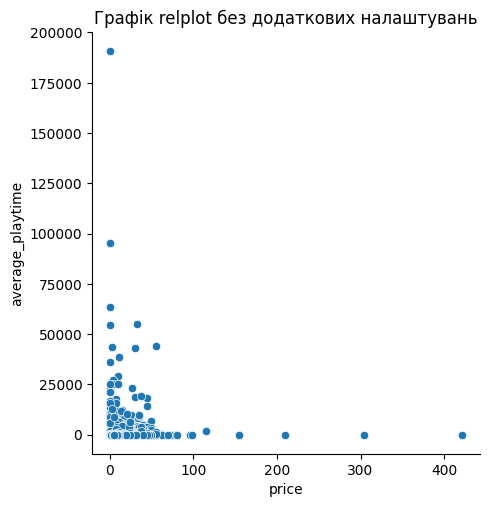

In [4]:
# Базовий графік relplot
sns.relplot(data=df, x='price', y='average_playtime')

plt.title('Графік relplot без додаткових налаштувань')
plt.show()

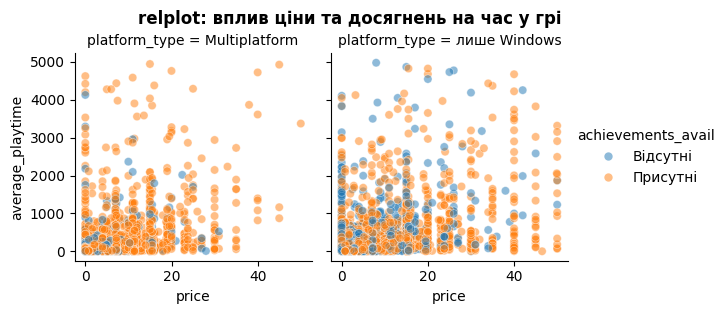

In [5]:
# Покращений графік relplot

# Видалення цінових та часових викидів
df_upd = df[ (df['price'] < 50) & (df['average_playtime'] > 0) & (df['average_playtime'] < 5000)].copy()
# Групування за типом платформи
df_upd['platform_type'] = np.where(df_upd['platforms'] == 'windows', 'лише Windows', 'Multiplatform')
# Категоризація наявності досягнень
df_upd['achievements_avail'] = np.where(df_upd['achievements'] > 0, 'Присутні', 'Відсутні')

sns.relplot(data=df_upd, x='price', y='average_playtime',
            hue='achievements_avail', col='platform_type',
            kind='scatter', alpha=0.5,
            height=3, aspect=1
)

plt.suptitle('relplot: вплив ціни та досягнень на час у грі', y=1.03, fontweight='bold')
plt.show()

# Висновок до Завдання 1:

Отже, під час виконання першого завдання я переконалась, що на базовому графіку зв'язок між змінними був абсолютно нечитабельним через масштабні цінові та часові аномалії. У вдосконаленій версії було відфільтровано викиди, додано напівпрозорість та розбито дані на панелі за платформами і кольором за наявністю досягнень. Це дозволило чітко зрозуміти, що гравці проводять найбільше часу в дешевих або безкоштовним іграх, причому наявність досягнень суттєво підвищує середній час гри на всіх цінових рівнях.


# Завдання 2. Seaborn: catplot — порівняння категорій

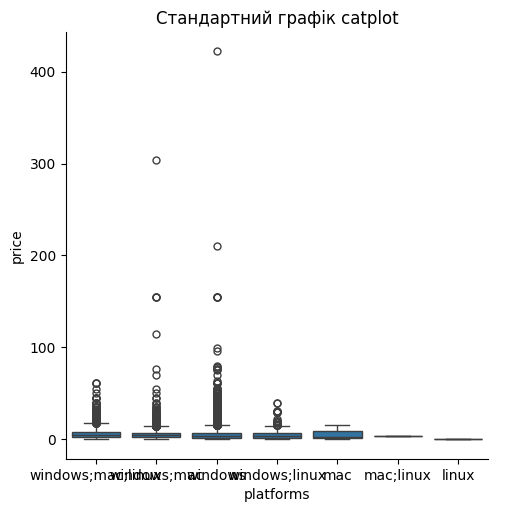

In [6]:
# Базовий графік catplot
sns.catplot(data=df, x='platforms', y='price', kind='box')
plt.title('Стандартний графік catplot')
plt.show()

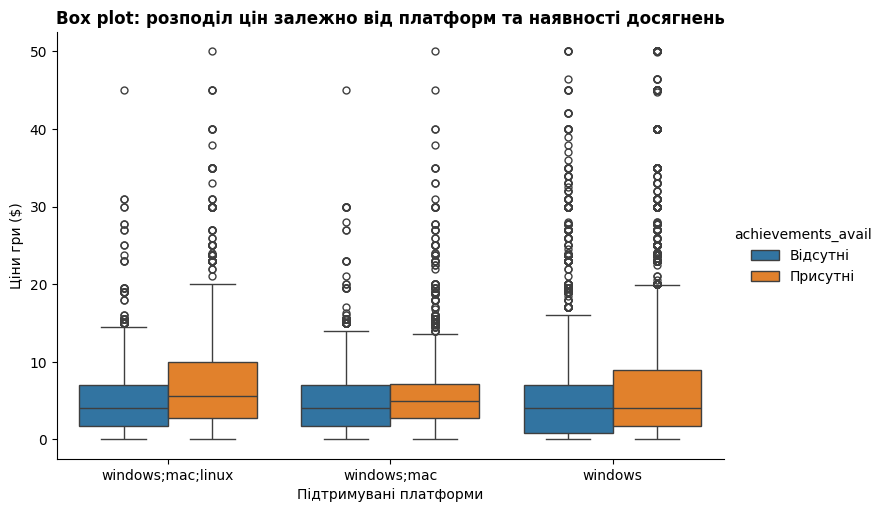

In [7]:
# Покращений графік catplot

# Відбір основних ПК-платформ
df_cat = df[df['platforms'].isin(['windows', 'windows;mac','windows;mac;linux'])].copy()
# Відкидаємо ігри дорожче 50$
df_cat = df_cat[df_cat['price'] < 50]
# Категоризація наявності досягнень
df_cat['achievements_avail'] = np.where(df_cat['achievements'] > 0, 'Присутні', 'Відсутні')

sns.catplot(
    data=df_cat,
    x='platforms',
    y='price',
    hue='achievements_avail',
    kind='box',
    height=5,
    aspect=1.5,
)

plt.title('Box plot: розподіл цін залежно від платформ та наявності досягнень', fontweight='bold')
plt.xlabel('Підтримувані платформи')
plt.ylabel('Ціни гри ($)')
plt.show()

# Висновок до Завдання 2:
Отже, під час виконання другого завдання я обрала тип графіка boxplot, тому що він дає можливість точно відобразити медіани та квартилі цін без спотворення екстремальних значень. Загалом базовий графік є нечитабельним через злиття категорій та сплющення від викидів. Для хорошого графіка було відфільтровано цінові аномалії, збільшено ширину малюнку для коректного відображення осей та додано параметр hue за наявністю досягнень. Це допомогло зрозуміти, що незалежно від платформи, ігри, що мають систему досягнень, у середньому мають дешо вищу медіанну вартість, ніж ігри без них.

# Завдання 3. Seaborn: displot — розподіли

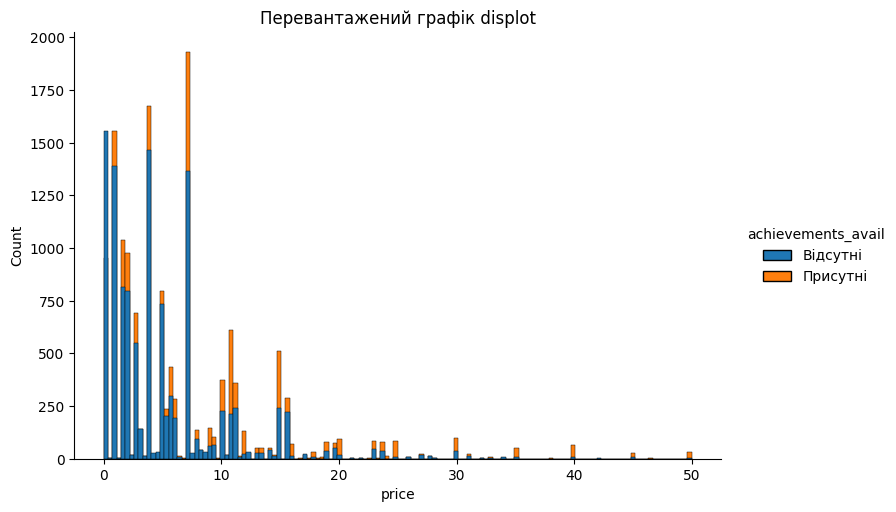

In [8]:
# Базовий графік displot
sns.displot(data=df_cat, x='price', hue='achievements_avail',kind='hist', alpha=1, height=5, aspect=1.5)
plt.title('Перевантажений графік displot')
plt.show()

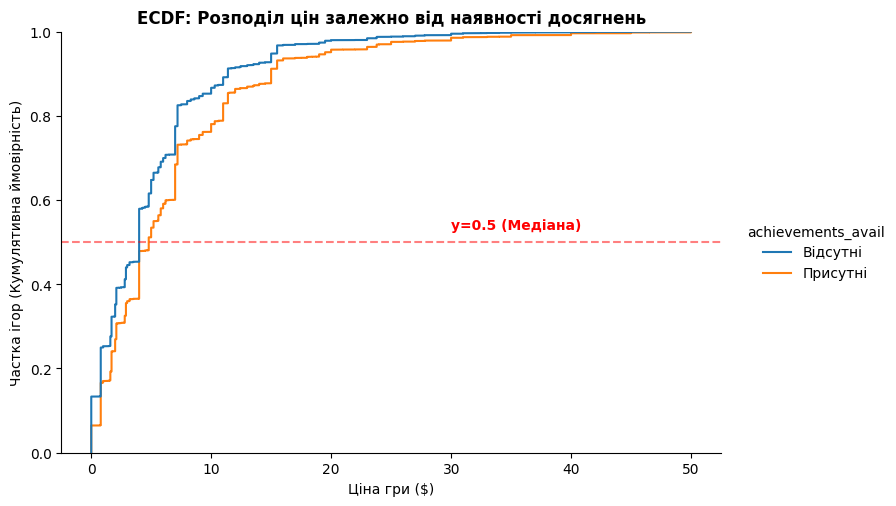

In [9]:
# Покращений графік displot
sns.displot(
    data=df_cat, x='price', hue='achievements_avail',
    kind='ecdf',
    height=5, aspect=1.5
)

plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.text(x=30, y=0.53, s='y=0.5 (Медіана)', color='red', fontweight='bold')

plt.title('ECDF: Розподіл цін залежно від наявності досягнень', fontweight='bold')
plt.xlabel('Ціна гри ($)')
plt.ylabel('Частка ігор (Кумулятивна ймовірність)')
plt.show()

# Висновок до Завдання 3:
Отже, під час виконання третього завдання при побудові базового графіку я переконалась, що стандартні гістограми без прозорості повністю зливаються, перевантажуючи візуалізацію та роблячи дані неможливими для інтерпретації.
Тому для вдосконаленого графіку я вирішила обрати кумулятивний розподіл (ECDF). Аналіз показав, що перетин кривої з лінією y=0.5 позначає точну медіану розподілу, тобто ціну, дешевше за яку коштують рівно 50% ігор у конкретній групі. На графіку чітко видно, що крива ігор із досягненнями перетинає цю медіану правіше. Це підтверджує певну закономірність, що ігри з досягненнями в середньому мають вищу вартість, ніж ігри без них.

# Завдання 4. Seaborn + Matplotlib: комбінований графік

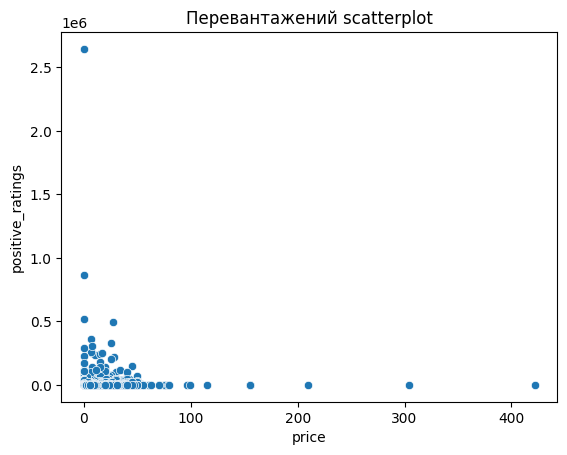

In [10]:
# Базовий графік seaborn + matplotlib
sns.scatterplot(data=df, x='price', y='positive_ratings')
plt.title('Перевантажений scatterplot')
plt.show()

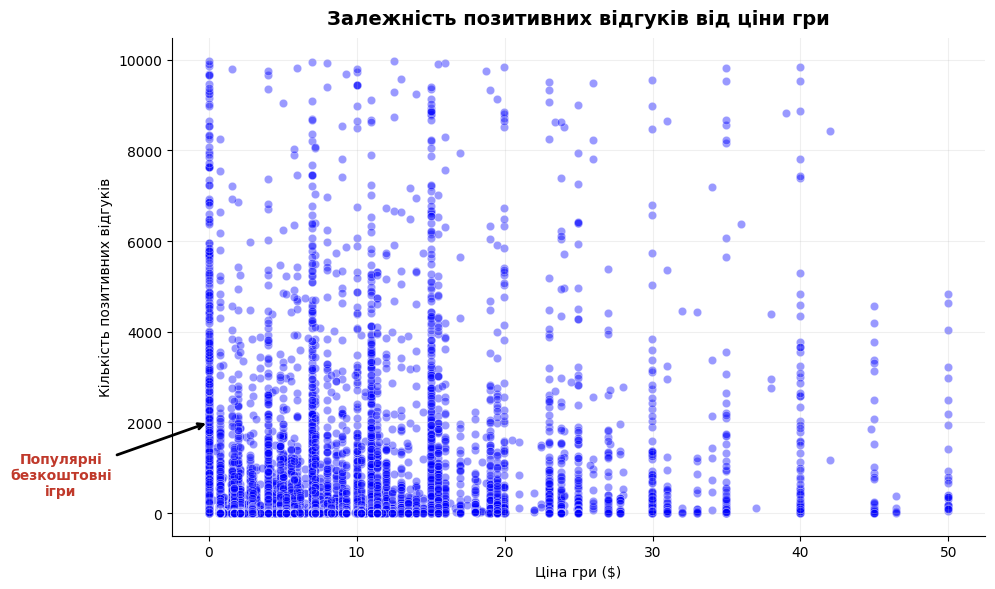

In [11]:
# Покращений графік scatterplot

# Очищення даних від викидів
df_scatterpl = df[(df['price'] < 50) & (df['positive_ratings'] > 0) & (df['positive_ratings'] < 10000)].copy()

fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(data=df_scatterpl, x='price', y='positive_ratings', alpha=0.4, color='blue', ax=ax)

ax.set_title('Залежність позитивних відгуків від ціни гри', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Ціна гри ($)')
ax.set_ylabel('Кількість позитивних відгуків')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)

ax.annotate('Популярні\nбезкоштовні\nігри',
            xy=(0,2000),
            xytext=(-10,400),
            fontsize=10,
            fontweight='bold',
            color='#c0392b',
            ha='center',
            arrowprops=dict(facecolor='#c0392b', arrowstyle='->', linewidth=2))

plt.tight_layout()
plt.show()


# Висновок до Завдання 4:
Отже, під час виконання четвертого завдання при побудові базового scatterplot я переконалась, що використання стандартних параметрів перевантажує графік, а замкнена рамка обтяжує візуальне сприйняття. Тому вдосконалений графік було передано в Matplotlib через параметр ax=ax та суттєво допрацьовано. Було додано кастомний заголовок, прибрано верхню та праву межі для полегшення дизайну та накладено сітку. Також за допомогою ax.annotate було додано вказівник на кластер популярний безкоштовних ігор. Щоб зберегти читабельність масиву даних, текст анотації було винесено у вільну зону графіка. Аналіз фінальної візуалізації показав, що найвища щільність позитивних оцінок зосереджена саме в сегменті бюджетних і безкоштовних ігор, тоді як для дорожчих проєктів кількість відгуків суттєво зменшується.

# Завдання 5. Plotly: інтерактивний scatter

In [12]:
# Базовий графік scatter
fig = px.scatter(
    df, x='average_playtime', y='positive_ratings',
    title='Поганий scatter: щільне накладання точок'
)
fig.show()

In [13]:
# Покращений графік scatter

# Прибираємо екстремальні викиди
df_plotly = df[(df['average_playtime'] > 0) & (df['average_playtime'] < 5000) & (df['positive_ratings'] >0) & (df['positive_ratings'] < 10000)].copy()
# Категоризація наявності досягнень
df_plotly['achievements_avail'] = np.where(df_plotly['achievements'] > 0, 'Присутні', 'Відсутні')

fig = px.scatter(
    df_plotly, x='average_playtime', y='positive_ratings',
    color='achievements_avail',
    hover_data=['name', 'developer', 'price'],
    title='Scatter: Вплив часу в грі на відгуки',
    opacity=0.3
)

fig.show()

# Висновок до Завдання 5:

Отже, під час виконання п'ятого завдання я з'ясувала, що на базовому графіку виникає проблема надмірного накладання точок, через що неможливо розрізнити та проаналізувати окремі об'єкти. Щоб це виправити, у вдосконаленій версії за допомогою Plotly я зменшила прозорість для візуального розвантаження скупчень та застосувала параметр hover_data. Завдяки ньому я змогла побачити те, чого не було видно на статичній версії. Аномальній точки перестали бути абстрактними координатами. Тепер при наведенні курсору можна чітко побачити, яка саме це гра, хто її розробник та яка її ціна, що дозволяє аналізувати конкретні популярні проєкти, а не лише загальний масив даних.

# Завдання 6. Plotly: вибір типу графіка

In [14]:
# Базовий графік pie chart

# Відбір топ-30 розробників
df_devs = df['developer'].value_counts().reset_index().head(30)

# Перейменування колонки таблиці
df_devs.columns = ['developer', 'count_game']

fig_bad = px.pie(
    df_devs,
    values='count_game',
    names='developer',
    title='Pie Chart для топ-30 розробників '
)

fig_bad.update_traces(textposition='inside', textinfo='percent+label')
fig_bad.show()

In [15]:
# Покращений графік Bar chart

# Сортування за зростанням кількості
df_devs_sort = df_devs.sort_values(by='count_game', ascending=True)

fig = px.bar(
    df_devs_sort,
    x='count_game',
    y='developer',
    orientation='h',
    text='count_game',
    color='developer',
    title='Bar chart кількості ігор за розробниками (топ-30)',
    labels={'count_game': 'Кількість ігор', 'developer': 'Компанія-розробник'},
    height=800
)

fig.update_layout(showlegend=False)
fig.update_traces(textposition='outside')
fig.show()

# Висновок до Завдання 6:
Отже, під час виконання шостого завдання я аналізувала топ-30 студій за кільстю випущених ігор. Для базового варіанту я свідомо обрала кругову діаграму (pie chart), яка виявилася категорично поганим варіантом, адже 30 категорій створили візуальний хаос: сектори злилися, а підписи стали нечитабельними.

Оптимальним вибором стала горизонтальна стовпчикова діаграма (bar chart). Вона дозволяє зручно порівнювати показники розробників між собою та вільно читати їхні довгі назви на осі Y. Завдяки збільшенню висоти графіка та винесенню числових значень за межі стовпчиків, візуалізація стала ідеально чистою, зручною для порівняння та не потребує зайвих легенд.

# Завдання 7. Plotly: ієрархічна візуалізація

In [16]:
# Підготовка даних для аналізу

# Фокус на лідерах ринку
top_devs = df['developer'].value_counts().nlargest(50).index
df_hier = df[df['developer'].isin(top_devs)].copy()

# Категоризація платформ
df_hier['platform_type'] = np.where(df_hier['platforms'] == 'windows', 'лише Windows', 'Multiplatform')

# Фактор залученості
df_hier['achievements_avail'] = np.where(df_hier['achievements'] > 0, 'With achievements', 'Without achievements')

# Очищення аномалій
df_hier = df_hier[df_hier['positive_ratings'] > 0]

In [17]:
# Базовий графік sunburst
fig_b = px.sunburst(
    df_hier,
    path=['name'],
    title='Поганий Sunburst: відсутність правильного шляху ієрархії'
)
fig_b.show()

In [18]:
# Покращений графік sunburst
fig_g = px.sunburst(
    df_hier,
    path=['platform_type', 'achievements_avail', 'developer'],
    values='positive_ratings',
    color='positive_ratings',
    color_continuous_scale='Blues',
    title='Розподіл позитивних відгуків за платформами, наявністю досягнень та студіями',
    height=700
)

fig_g.update_traces(textinfo='label+percent parent')
fig_g.show()

# Висновок до Завдання 7:
Отже, під час виконання сьомого завдання було побудовано ієрархічну візуалізацію (sunburst chart). Базовий варіант без правильного шляху (path) перетворився на нечитабельне кільце, оскільки всі об'єкти без групування опинилися на одному рівні.
Для вдосконаленого графіка було побудовано такий шлях ієрархії: від типу платформи через наявність досягнень до конкретної студії (серед 50 лідерів). При цьому площа кожного сегмента наочно відображає обсяг позитивних відгуків від гравців. Найбільшою перевагою цього графіка є можливість глибинного дослідження даних (drill-down). При взаємодії з графіком чітко видно величезний відрив студії Valve від усіх інших розробників. А функція наближення допомагає кліком розгорнути навіть найменші сегменти, щоб детально роздивитися частки іших розробників.

# Завдання 8. Порівняння трьох інструментів

In [19]:
# Відбір топ-1000 найпопулярнішмх ігор згідно з позитивними відгуками
df_scatter = df.nlargest(1000, 'positive_ratings')

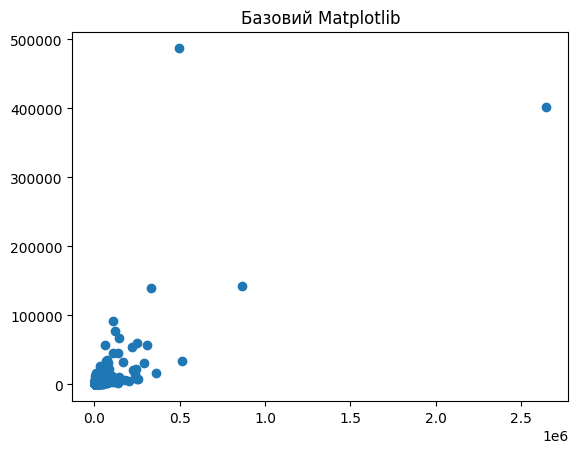

In [20]:
# Базовий графік matplotlib
plt.scatter(df_scatter['positive_ratings'], df_scatter['negative_ratings'])
plt.title('Базовий Matplotlib')
plt.show()

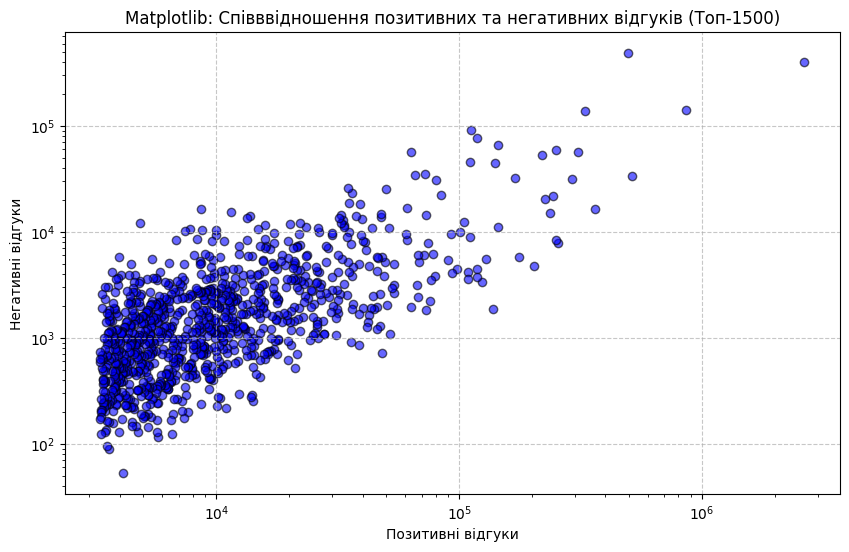

In [21]:
# Покращений графік matplotlib
plt.figure(figsize=(10,6))

plt.scatter(df_scatter['positive_ratings'], df_scatter['negative_ratings'], alpha=0.6, color='blue', edgecolor='black')
plt.title('Matplotlib: Співввідношення позитивних та негативних відгуків (Топ-1500)')
plt.xlabel('Позитивні відгуки')
plt.ylabel('Негативні відгуки')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.show()

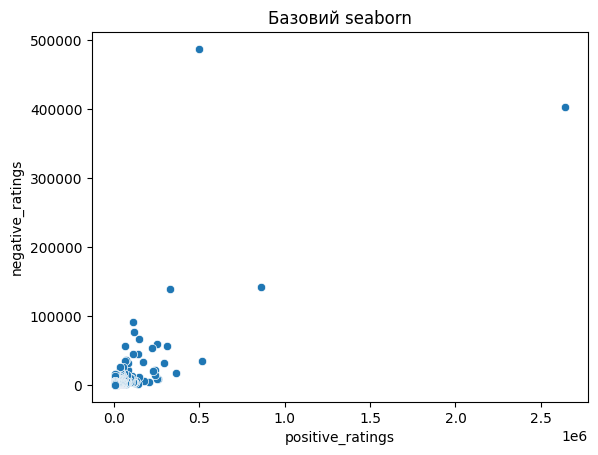

In [22]:
# Базовий графік seaborn
sns.scatterplot(data=df_scatter, x='positive_ratings', y='negative_ratings')
plt.title('Базовий seaborn')
plt.show()

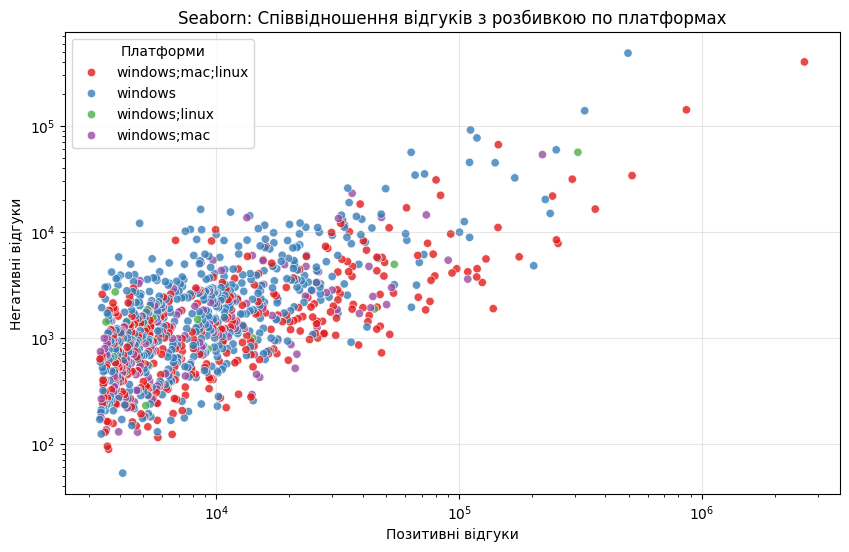

In [23]:
# Покращений графік seaborn
plt.figure(figsize=(10,6))

sns.scatterplot(data=df_scatter,
                x='positive_ratings',
                y='negative_ratings',
                hue='platforms',
                palette='Set1',
                alpha=0.8
                )
plt.title('Seaborn: Співвідношення відгуків з розбивкою по платформах')
plt.xlabel('Позитивні відгуки')
plt.ylabel('Негативні відгуки')
plt.legend(title='Платформи')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [24]:
# Базовий графік plotly
fig_b = px.scatter(df_scatter, x='positive_ratings', y='negative_ratings', title='Базовий plotly')
fig_b.show()

In [25]:
# Покращений графік plotly
fig_g = px.scatter(
    df_scatter,
    x='positive_ratings',
    y='negative_ratings',
    color='platforms',
    hover_name='name',
    title='Plotly: Інтерактивне співвідношення відгуків',
    labels={'positive_ratings': 'Позитивні відгуки', 'negative_ratings': 'Негативні відгуки', 'platforms': 'Платформа'},
    template='plotly_white',
    opacity=0.7,
    log_x=True,
    log_y=True
)
fig_g.show()

# Висновок до Завдання 8:
Отже, під час виконання восьмого завдання для порівняння трьох інструментів я обрала діаграму розсіювання (Scatter plot). Так як головною проблемою базових графіків є залипання точок через ігри-гіганти, основні зусилля під час створення покращених версій пішли на застосування логарифмічної шкали. Робота з Matplotlib показала, що його плюсом є абсолютний контроль над усіма візуальними деталями, а мінусом - потреба писати найбільше коду, викликаючи окремі функції для кожної зміни осей. Seaborn має перевагу в мінімальних зусиллях для естетики: додавання лише одного параметра миттєво розфарбовує дані та створює легенду, проте його недоліком залишається залежність від синтаксису Matplotlib для налаштування розміру полотна. Plotly виявився найбільш функціональним, адже інтерактивність і логарифмічні осі вмикаються простими аргументами всередині однієї функції, але його мінусом є специфічний синтаксис, до якого важко адаптуватися після класичних бібліотек.

# Завдання 9. Storytelling: графік для нетехнічної аудиторії

Axes-level функції, наприклад, sns.scatterplot, будують графік на вже існуючій координатній площині, тоді як figure-level функції, наприклад, sns.displot, самостійно створюють нове вікно. У 4-му завданні я формувала єдину сітку з кількох графіків за допомогою plt.subplots(), тому потрібно було використовувати саме axes-level функції. Лише вони приймають аршумент ax=, що дозволило чітко вказати, у якій саме комірці макета має опинитися кожен графік, не ламаючи загальну структуру появою нових вікон.

In [26]:
# Додавання колонки achievements_avail, якщо її немає
if 'achievements_avail' not in df.columns:
  df['achievements_avail'] = np.where(df['achievements'] > 0, 'With achievements', ' Without achievements')

# Обрахунок медіани рейтингу для обох категорій
df_story = df.groupby('achievements_avail')['positive_ratings'].median().reset_index()

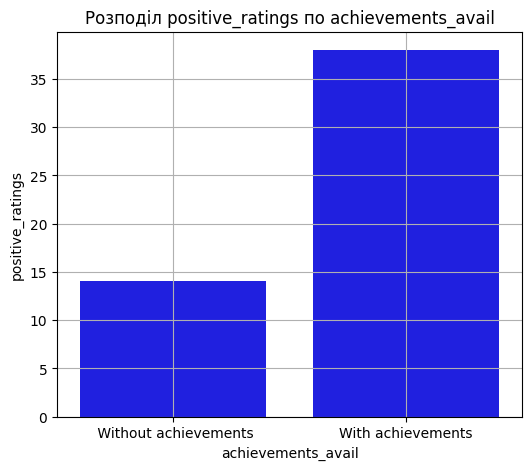

In [27]:
# Базовий графік
plt.figure(figsize=(6,5))
sns.barplot(data=df_story, x='achievements_avail', y='positive_ratings', color='blue')
plt.title('Розподіл positive_ratings по achievements_avail')
plt.grid(True)
plt.show()

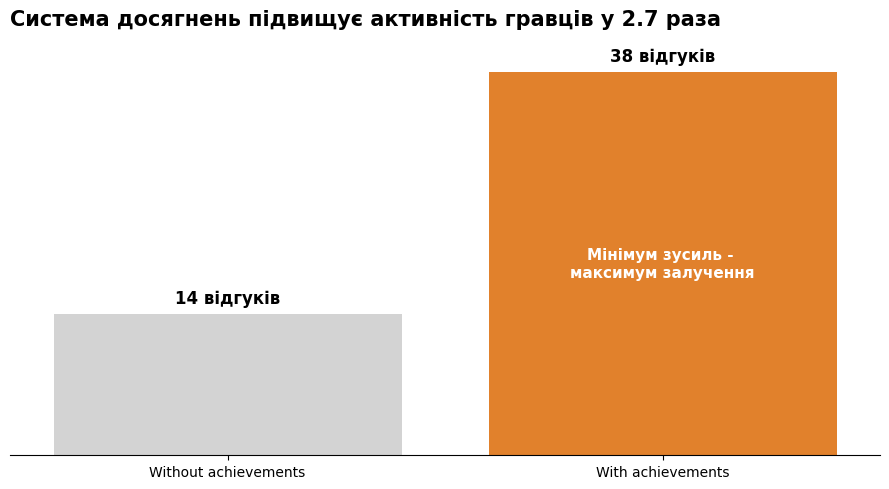

In [28]:
# Покращений графік

# Очищення даних від можливих пробілів
df_story['achievements_avail'] = df_story['achievements_avail'].str.strip()

fig, ax = plt.subplots(figsize=(9,5))

colors = ['#ff7f0e' if x == 'With achievements' else '#d3d3d3' for x in df_story['achievements_avail']]
sns.barplot(data=df_story, x='achievements_avail', y='positive_ratings', hue='achievements_avail', palette=colors, legend=False, ax=ax)

# Стираємо всі зайві рамки, сітки та осі
sns.despine(left=True, bottom=False)
ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel("")

# Підписи над стовпцями
for container in ax.containers:
  ax.bar_label(container, fmt='%d відгуків', padding=5, fontsize=12, fontweight='bold')

val_yes = df_story.loc[df_story['achievements_avail'] == 'With achievements', 'positive_ratings'].values[0]
val_no = df_story.loc[df_story['achievements_avail'] == 'Without achievements', 'positive_ratings'].values[0]

ax.set_title(f"Система досягнень підвищує активність гравців у {val_yes / val_no:.1f} раза",
             loc='left', fontsize=15, fontweight='bold', pad=20)

# Текстова анотація
idx_yes = df_story[df_story['achievements_avail'] == 'With achievements'].index[0]
ax.text(idx_yes, val_yes * 0.5, "Мінімум зусиль - \nмаксимум залучення",
        ha='center', va='center', color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Висновки до Завдання 9:

**1. Оптимізація розподілу ресурсів для досягнення найвищої конверсії**

Дані свідчать, що наявність ігрових досягнень збільшує активність аудиторії у 2.7 раза. Для керівника проєкту це означає, що час, витрачений на створення 'ачівок', принесе продукту непропорційно велику користь. Навіть за умов жорстко обмеженого бюджету необхідно виділяти час розробників на створення базового набору досягнень, тому що це найдешевший спосіб суттєво підвищити показники залученості гравців.

**2. Оптимізація життєвого циклу продукту**

Інтеграція системи досягнень у вже існуючі проєкти студії виступає найбільш рентабельним інструментом повторного залучення гравців. Випуск такого функціоналу не вимагає значних інвестицій у створення нового сюжетного чи візуального контенту, проте гарантовано генерує сплеск активності спільноти. Нова хвиля відгуків змушує алгоритми Steam підвищувати видимість продукту, що забезпечує нові продажі старих ігор при мінімальних витратах на розробку.